1. Setup and Installations

In [1]:
# Install required packages
!pip install transformers[torch] --upgrade
!pip install transformers==4.25.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 36.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

Imports and Setup

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import pickle
import warnings
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, LSTM, Bidirectional

# Suppress warnings
warnings.filterwarnings('ignore')

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Data Loading and Exploration

Dataset loaded successfully with shape: (47692, 2)

First few rows of the dataset:
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying

Missing values:
tweet_text            0
cyberbullying_type    0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB
None


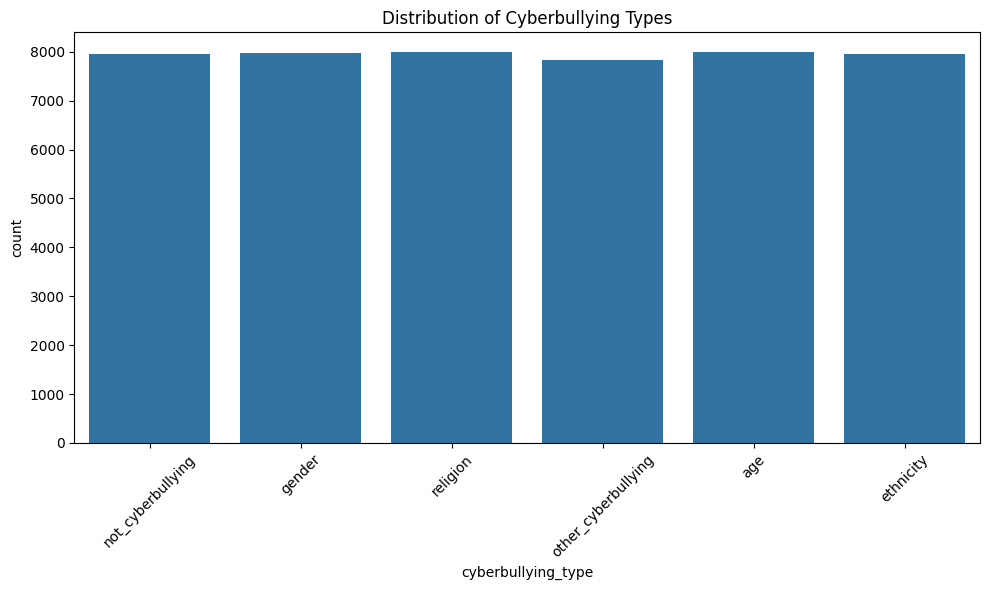

Class distribution plot saved


In [2]:
# Load the dataset
try:
    dataset_path = '/content/cyberbullying_tweets.csv'
    df = pd.read_csv(dataset_path)
    print(f"Dataset loaded successfully with shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Create sample dataset for demonstration
    print("Creating sample dataset for demonstration")
    data = {
        'tweet_text': [
            "You are such a loser, no one likes you!",
            "Had a great day at the beach with friends!",
            "Why don't you just kill yourself, you're worthless",
            "Just watched the new movie, it was amazing!",
            "I hate you and everything about you, stupid idiot",
            "Congratulations on your new job! So happy for you"
        ],
        'cyberbullying_type': ['cyberbullying', 'not_cyberbullying', 'cyberbullying',
                              'not_cyberbullying', 'cyberbullying', 'not_cyberbullying']
    }
    df = pd.DataFrame(data)
    print(f"Sample dataset created with shape: {df.shape}")

# Display dataset information
print("\nFirst few rows of the dataset:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDataset info:")
print(df.info())

# Plot class distribution
if 'cyberbullying_type' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='cyberbullying_type', data=df)
    plt.title('Distribution of Cyberbullying Types')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('cyberbullying_distribution.png')
    plt.show()
    print("Class distribution plot saved")

 Text Preprocessing

In [3]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
def preprocess_text(text):
    """Preprocess text for model training and prediction"""
    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^\w\s]|\d', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into text
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

# Apply preprocessing to the text column
text_column = 'tweet_text' if 'tweet_text' in df.columns else df.columns[0]
df['preprocessed_text'] = df[text_column].apply(preprocess_text)

# Display sample preprocessed text
print("\nSample Preprocessed Text:")
for i in range(min(3, len(df))):
    print(f"Original: {df[text_column].iloc[i]}")
    print(f"Preprocessed: {df['preprocessed_text'].iloc[i]}")
    print("---")

# Convert cyberbullying types to numerical labels
label_encoder = LabelEncoder()
label_column = 'cyberbullying_type' if 'cyberbullying_type' in df.columns else df.columns[1]
df['label'] = label_encoder.fit_transform(df[label_column])
print("\nNumerical labels assigned:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))


Sample Preprocessed Text:
Original: In other words #katandandre, your food was crapilicious! #mkr
Preprocessed: word food crapilicious
---
Original: Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc
Preprocessed: white
---
Original: @XochitlSuckkks a classy whore? Or more red velvet cupcakes?
Preprocessed: classy whore red velvet cupcake
---

Numerical labels assigned: {'age': 0, 'ethnicity': 1, 'gender': 2, 'not_cyberbullying': 3, 'other_cyberbullying': 4, 'religion': 5}


Data Splitting

In [5]:
# Split the data into training, validation, and testing sets
X = df['preprocessed_text']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nData split sizes:")
print(f"Training: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")


Data split sizes:
Training: 33384 samples
Validation: 7154 samples
Testing: 7154 samples


TF-IDF Vectorization

In [6]:
# Create TF-IDF vectors
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

Model 1: Naive Bayes

In [7]:
# Train and evaluate Naive Bayes model
print("\n===== TF-IDF with Naive Bayes =====")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Evaluate on validation set
y_val_pred_nb = nb_model.predict(X_val_tfidf)
nb_val_accuracy = accuracy_score(y_val, y_val_pred_nb)
print(f"Naive Bayes - Validation Accuracy: {nb_val_accuracy:.4f}")
print(classification_report(y_val, y_val_pred_nb))


===== TF-IDF with Naive Bayes =====
Naive Bayes - Validation Accuracy: 0.7548
              precision    recall  f1-score   support

           0       0.76      0.97      0.85      1199
           1       0.84      0.93      0.88      1194
           2       0.80      0.82      0.81      1196
           3       0.65      0.37      0.47      1192
           4       0.61      0.48      0.53      1173
           5       0.77      0.95      0.85      1200

    accuracy                           0.75      7154
   macro avg       0.74      0.75      0.73      7154
weighted avg       0.74      0.75      0.74      7154



Model 2: SVM

In [8]:
# Train and evaluate SVM model
print("\n===== TF-IDF with SVM =====")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Evaluate on validation set
y_val_pred_svm = svm_model.predict(X_val_tfidf)
svm_val_accuracy = accuracy_score(y_val, y_val_pred_svm)
print(f"SVM - Validation Accuracy: {svm_val_accuracy:.4f}")
print(classification_report(y_val, y_val_pred_svm))


===== TF-IDF with SVM =====
SVM - Validation Accuracy: 0.8016
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1199
           1       0.96      0.97      0.96      1194
           2       0.86      0.83      0.84      1196
           3       0.53      0.52      0.53      1192
           4       0.55      0.57      0.56      1173
           5       0.96      0.95      0.95      1200

    accuracy                           0.80      7154
   macro avg       0.80      0.80      0.80      7154
weighted avg       0.80      0.80      0.80      7154



Sequence Processing for Deep Learning Models

In [9]:
# Prepare sequence data for deep learning models
max_words = 10000
max_length = 100
embedding_dim = 100

# Tokenization
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Number of classes for output layer
num_classes = len(np.unique(y))

Model 3: CNN

In [10]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# ===== CNN with Word Embeddings =====
print("\n===== CNN with Word Embeddings =====")

# Hyperparameters
max_words = 10000      # Vocabulary size
max_length = 100       # Sequence length
embedding_dim = 100    # Embedding output size

# Tokenization
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Number of classes
num_classes = len(np.unique(y))  # Ensure `y` includes all class labels

# Build CNN Model
cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_length),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Manually build the model to view summary before training
cnn_model.build(input_shape=(None, max_length))
cnn_model.summary()



===== CNN with Word Embeddings =====
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          1000000   
                                                                 
 conv1d (Conv1D)             (None, 96, 128)           64128     
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 6)                 390       
                  

In [28]:
pip install tensorflow==2.12  # Or the version you're targeting


INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 10.5 MB/s eta 0:00:00
  Att

In [11]:
# Train the CNN model
cnn_history = cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32
)




Epoch 1/5
1044/1044 [==============================] - 47s 43ms/step - loss: 0.6119 - accuracy: 0.7519 - val_loss: 0.4350 - val_accuracy: 0.8158
Epoch 2/5
1044/1044 [==============================] - 36s 34ms/step - loss: 0.3941 - accuracy: 0.8415 - val_loss: 0.4341 - val_accuracy: 0.8165
Epoch 3/5
1044/1044 [==============================] - 37s 35ms/step - loss: 0.3064 - accuracy: 0.8773 - val_loss: 0.4774 - val_accuracy: 0.8114
Epoch 4/5
1044/1044 [==============================] - 37s 35ms/step - loss: 0.2426 - accuracy: 0.9013 - val_loss: 0.5340 - val_accuracy: 0.8081
Epoch 5/5
1044/1044 [==============================] - 36s 35ms/step - loss: 0.1945 - accuracy: 0.9181 - val_loss: 0.6149 - val_accuracy: 0.8067


In [12]:
# Evaluate CNN model
y_val_pred_cnn = np.argmax(cnn_model.predict(X_val_pad, verbose=0), axis=1)
cnn_val_accuracy = accuracy_score(y_val, y_val_pred_cnn)
print(f"CNN - Validation Accuracy: {cnn_val_accuracy:.4f}")
print(classification_report(y_val, y_val_pred_cnn))


CNN - Validation Accuracy: 0.8067
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1199
           1       0.98      0.96      0.97      1194
           2       0.85      0.83      0.84      1196
           3       0.55      0.49      0.52      1192
           4       0.56      0.65      0.60      1173
           5       0.95      0.95      0.95      1200

    accuracy                           0.81      7154
   macro avg       0.81      0.81      0.81      7154
weighted avg       0.81      0.81      0.81      7154



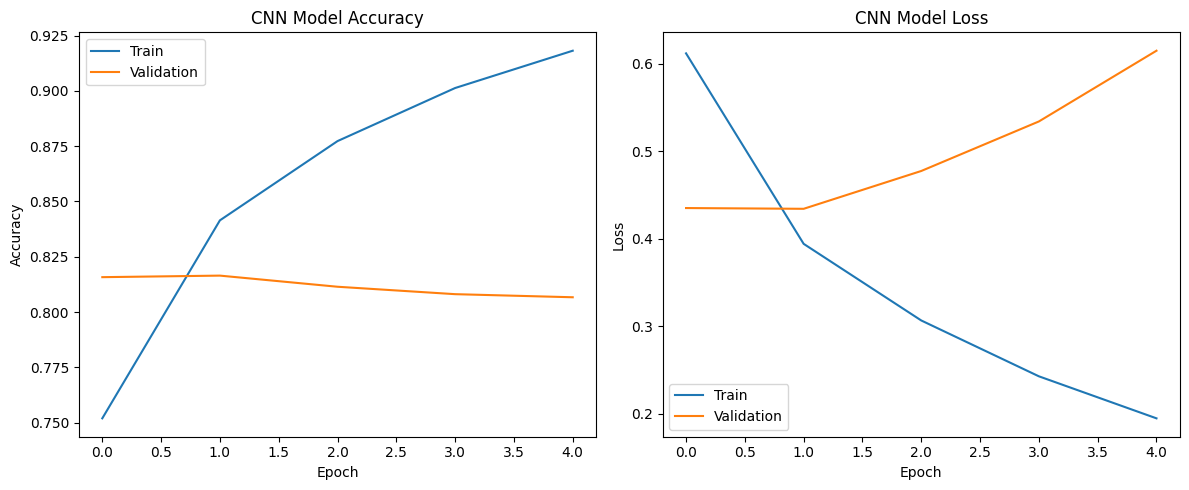

In [13]:

# Plot CNN training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='Train')
plt.plot(cnn_history.history['val_accuracy'], label='Validation')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='Train')
plt.plot(cnn_history.history['val_loss'], label='Validation')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('cnn_training_history.png')
plt.show()

Model 4: LSTM

In [14]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

print("\n===== LSTM Model =====")

# Hyperparameters
embedding_dim = 100
max_words = 10000
max_length = 100

# Number of classes (assuming y has all labels)
num_classes = len(np.unique(y))

# Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Manually build model to show summary
lstm_model.build(input_shape=(None, max_length))
lstm_model.summary()



===== LSTM Model =====
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 100)          1000000   
                                                                 
 bidirectional (Bidirectiona  (None, 128)              84480     
 l)                                                              
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 1,093,126
Trainable params: 1,093,126
Non-trainable params: 0
____________________

In [15]:
# Train the LSTM model
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    verbose=1
)


Epoch 1/5
1044/1044 [==============================] - 161s 150ms/step - loss: 0.6626 - accuracy: 0.7150 - val_loss: 0.4619 - val_accuracy: 0.7970
Epoch 2/5
1044/1044 [==============================] - 159s 152ms/step - loss: 0.4287 - accuracy: 0.8191 - val_loss: 0.4544 - val_accuracy: 0.8061
Epoch 3/5
1044/1044 [==============================] - 163s 157ms/step - loss: 0.3556 - accuracy: 0.8561 - val_loss: 0.4689 - val_accuracy: 0.8124
Epoch 4/5
1044/1044 [==============================] - 163s 156ms/step - loss: 0.3017 - accuracy: 0.8792 - val_loss: 0.5027 - val_accuracy: 0.8033
Epoch 5/5
1044/1044 [==============================] - 159s 153ms/step - loss: 0.2586 - accuracy: 0.8947 - val_loss: 0.5722 - val_accuracy: 0.8026


In [16]:
# Evaluate LSTM model
y_val_pred_lstm = np.argmax(lstm_model.predict(X_val_pad), axis=1)
print("\nLSTM - Validation Results:")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_lstm):.4f}")
print(classification_report(y_val, y_val_pred_lstm))



224/224 [==============================] - 7s 28ms/step

LSTM - Validation Results:
Accuracy: 0.8026
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1199
           1       0.97      0.96      0.97      1194
           2       0.84      0.84      0.84      1196
           3       0.53      0.50      0.51      1192
           4       0.57      0.63      0.60      1173
           5       0.93      0.94      0.94      1200

    accuracy                           0.80      7154
   macro avg       0.80      0.80      0.80      7154
weighted avg       0.81      0.80      0.80      7154



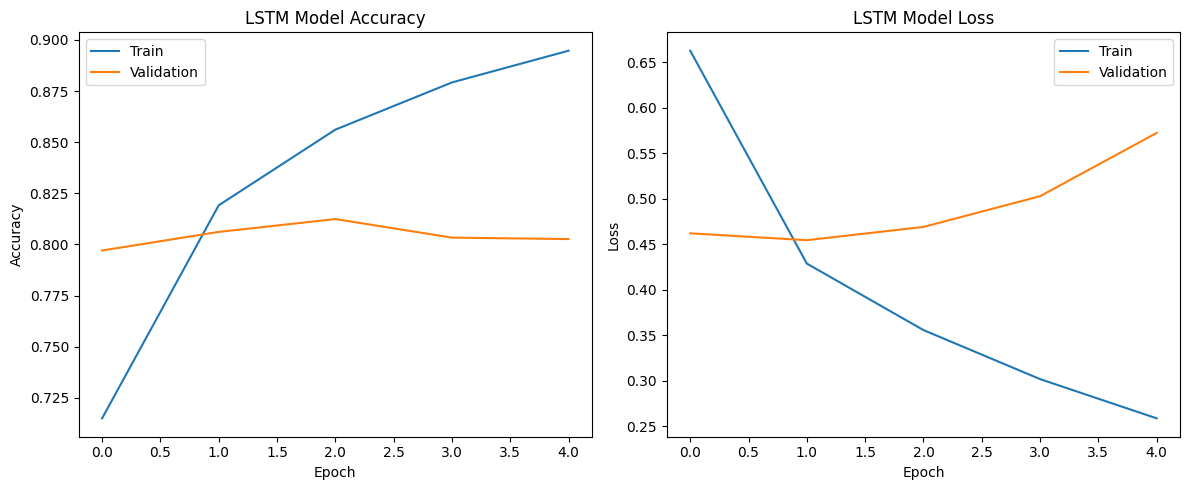

LSTM training history plot saved


In [17]:
# Plot LSTM training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Train')
plt.plot(lstm_history.history['val_accuracy'], label='Validation')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Train')
plt.plot(lstm_history.history['val_loss'], label='Validation')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_training_history.png')
plt.show()
plt.close()
print("LSTM training history plot saved")

Model 5: BERT Model (Fixed Implementation)

In [18]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from tqdm import tqdm

# Check prerequisites
if len(df) > 10 and torch.cuda.is_available():
    print("\n===== BERT Model =====")



===== BERT Model =====


Load Tokenizer and Model

In [19]:
    # Load tokenizer and model
    bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        num_labels=len(np.unique(y))
    )


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly i

Tokenization Function

In [20]:
    def tokenize_for_bert(texts, max_length=128):
        return bert_tokenizer(
            texts.tolist(),
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )


Custom PyTorch Dataset

In [21]:
    class BERTDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels

        def __getitem__(self, idx):
            item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels.iloc[idx])
            return item

        def __len__(self):
            return len(self.labels)


Tokenize and Prepare DataLoaders

In [22]:
    # Tokenize
    train_encodings = tokenize_for_bert(X_train)
    val_encodings = tokenize_for_bert(X_val)

    # Datasets
    train_dataset = BERTDataset(train_encodings, y_train)
    val_dataset = BERTDataset(val_encodings, y_val)

    # DataLoaders
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=8)


Model to Device & Optimizer

In [23]:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    bert_model.to(device)

    optimizer = AdamW(bert_model.parameters(), lr=5e-5)


Training Loop

In [24]:
    print(f"Training BERT model on {device}")
    for epoch in range(1):  # One epoch for demo
        print(f"Epoch {epoch+1}")
        bert_model.train()
        train_loss = 0
        progress_bar = tqdm(train_loader, desc="Training")

        for batch in progress_bar:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            train_loss += loss.item()
            loss.backward()
            optimizer.step()

            progress_bar.set_postfix({'loss': train_loss / (progress_bar.n + 1)})


Training BERT model on cuda
Epoch 1


Training: 100%|██████████| 4173/4173 [12:49<00:00,  5.42it/s, loss=0.521]


Validation Loop

In [25]:
    bert_model.eval()
    val_loss = 0
    predictions = []
    references = []

    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc="Validation")
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            val_loss += loss.item()

            logits = outputs.logits
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(pred)
            references.extend(labels.cpu().numpy())

            progress_bar.set_postfix({'loss': val_loss / (progress_bar.n + 1)})


Validation: 100%|██████████| 895/895 [00:53<00:00, 16.85it/s, loss=0.462]


Metrics and Output

In [26]:
    accuracy = accuracy_score(references, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(references, predictions, average='weighted')

    print(f"Validation Results - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(classification_report(references, predictions))

    bert_preds = predictions


Validation Results - Accuracy: 0.8151, Precision: 0.8391, Recall: 0.8151, F1: 0.7998
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1199
           1       0.97      0.96      0.97      1194
           2       0.81      0.90      0.85      1196
           3       0.77      0.26      0.39      1192
           4       0.53      0.84      0.65      1173
           5       0.95      0.96      0.95      1200

    accuracy                           0.82      7154
   macro avg       0.84      0.81      0.80      7154
weighted avg       0.84      0.82      0.80      7154



Final Model Evaluation


===== Final Model Evaluation =====

Naive Bayes - Test Accuracy: 0.7498
              precision    recall  f1-score   support

           0       0.75      0.97      0.85      1199
           1       0.84      0.93      0.89      1194
           2       0.82      0.82      0.82      1196
           3       0.66      0.36      0.47      1192
           4       0.57      0.46      0.51      1174
           5       0.76      0.94      0.84      1199

    accuracy                           0.75      7154
   macro avg       0.73      0.75      0.73      7154
weighted avg       0.74      0.75      0.73      7154


SVM - Test Accuracy: 0.8082
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1199
           1       0.97      0.98      0.97      1194
           2       0.87      0.83      0.85      1196
           3       0.54      0.52      0.53      1192
           4       0.56      0.61      0.58      1174
           5       0.95      0

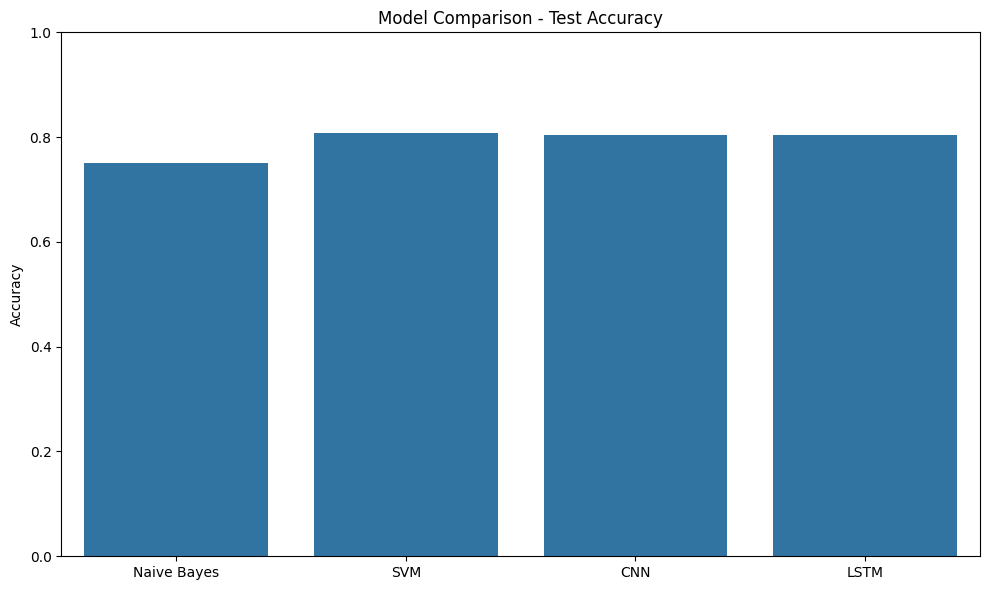


Best performing model: SVM with accuracy 0.8082


In [27]:
# Evaluate all models on the test set
print("\n===== Final Model Evaluation =====")

# Naive Bayes test evaluation
y_test_pred_nb = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, y_test_pred_nb)
print(f"\nNaive Bayes - Test Accuracy: {nb_accuracy:.4f}")
print(classification_report(y_test, y_test_pred_nb))

# SVM test evaluation
y_test_pred_svm = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, y_test_pred_svm)
print(f"\nSVM - Test Accuracy: {svm_accuracy:.4f}")
print(classification_report(y_test, y_test_pred_svm))

# CNN test evaluation
y_test_pred_cnn = np.argmax(cnn_model.predict(X_test_pad, verbose=0), axis=1)
cnn_accuracy = accuracy_score(y_test, y_test_pred_cnn)
print(f"\nCNN - Test Accuracy: {cnn_accuracy:.4f}")
print(classification_report(y_test, y_test_pred_cnn))

# LSTM test evaluation
y_test_pred_lstm = np.argmax(lstm_model.predict(X_test_pad, verbose=0), axis=1)
lstm_accuracy = accuracy_score(y_test, y_test_pred_lstm)
print(f"\nLSTM - Test Accuracy: {lstm_accuracy:.4f}")
print(classification_report(y_test, y_test_pred_lstm))

# Compare models
models = ['Naive Bayes', 'SVM', 'CNN', 'LSTM']
accuracies = [nb_accuracy, svm_accuracy, cnn_accuracy, lstm_accuracy]

# Identify best model
best_model_index = accuracies.index(max(accuracies))
best_model_name = models[best_model_index]

# Plot model comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies)
plt.title('Model Comparison - Test Accuracy')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()
print(f"\nBest performing model: {best_model_name} with accuracy {max(accuracies):.4f}")

Confusion Matrix for Best Model


===== Confusion Matrix for Best Model =====


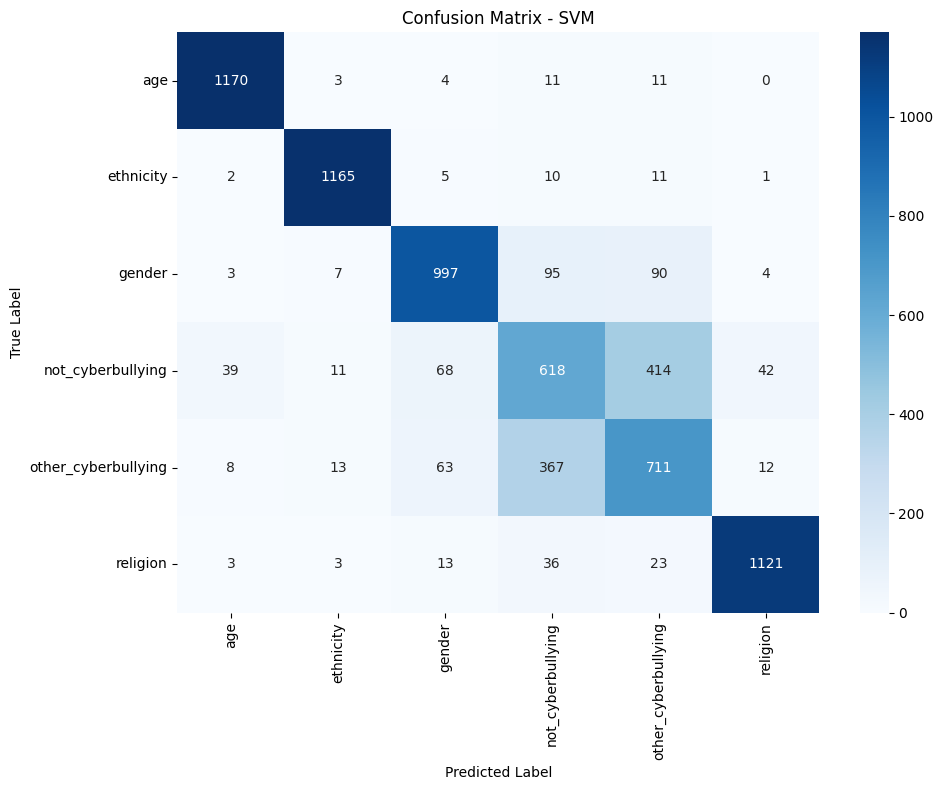

In [28]:
# Create confusion matrix for the best model
print("\n===== Confusion Matrix for Best Model =====")

# Get predictions from the best model
if best_model_index == 0:  # Naive Bayes
    best_predictions = y_test_pred_nb
elif best_model_index == 1:  # SVM
    best_predictions = y_test_pred_svm
elif best_model_index == 2:  # CNN
    best_predictions = y_test_pred_cnn
else:  # LSTM
    best_predictions = y_test_pred_lstm

# Create confusion matrix
cm = confusion_matrix(y_test, best_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

Save Best Model

In [29]:
# Create directory for model saving
if not os.path.exists('models'):
    os.makedirs('models')

# Save the best model
print("\n===== Saving Best Model =====")
if best_model_index == 0:  # Naive Bayes
    with open('models/best_model_naive_bayes.pkl', 'wb') as f:
        pickle.dump((nb_model, tfidf_vectorizer, label_encoder), f)
    print("Naive Bayes model saved as 'models/best_model_naive_bayes.pkl'")

elif best_model_index == 1:  # SVM
    with open('models/best_model_svm.pkl', 'wb') as f:
        pickle.dump((svm_model, tfidf_vectorizer, label_encoder), f)
    print("SVM model saved as 'models/best_model_svm.pkl'")

elif best_model_index == 2:  # CNN
    # Save the model
    cnn_model.save('models/best_model_cnn.h5')

    # Save tokenizer and label encoder
    with open('models/cnn_tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)
    with open('models/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print("CNN model and related files saved in 'models/' directory")

else:  # LSTM
    # Save the model
    lstm_model.save('models/best_model_lstm.h5')

    # Save tokenizer and label encoder
    with open('models/lstm_tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)
    with open('models/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print("LSTM model and related files saved in 'models/' directory")


===== Saving Best Model =====
SVM model saved as 'models/best_model_svm.pkl'


Create Prediction Functions

In [30]:
# Create prediction functions for each model type
def predict_with_nb(text, model, vectorizer, le):
    """Predict using Naive Bayes model"""
    preprocessed = preprocess_text(text)
    text_tfidf = vectorizer.transform([preprocessed])
    prediction = model.predict(text_tfidf)[0]
    return le.classes_[prediction]

def predict_with_svm(text, model, vectorizer, le):
    """Predict using SVM model"""
    preprocessed = preprocess_text(text)
    text_tfidf = vectorizer.transform([preprocessed])
    prediction = model.predict(text_tfidf)[0]
    return le.classes_[prediction]

def predict_with_dl_model(text, model, tokenizer, le, max_length=100):
    """Predict using deep learning models (CNN, LSTM)"""
    preprocessed = preprocess_text(text)
    text_seq = tokenizer.texts_to_sequences([preprocessed])
    text_pad = pad_sequences(text_seq, maxlen=max_length)
    prediction = np.argmax(model.predict(text_pad, verbose=0), axis=1)[0]
    return le.classes_[prediction]

Multi-Model Prediction System

In [37]:
def simple_cyberbullying_detector():
    """Simple interface for testing only the best model"""
    print("\n===== Simple Cyberbullying Detector =====")
    print("Enter text to check if it's cyberbullying (type 'exit' to quit):")

    # Determine which model to use based on the best_model_index
    if best_model_index == 0:
        model_type = "Naive Bayes"
        prediction_function = lambda text: nb_model.predict(tfidf_vectorizer.transform([preprocess_text(text)]))[0]
    elif best_model_index == 1:
        model_type = "SVM"
        prediction_function = lambda text: svm_model.predict(tfidf_vectorizer.transform([preprocess_text(text)]))[0]
    elif best_model_index == 2:
        model_type = "CNN"
        prediction_function = lambda text: np.argmax(cnn_model.predict(
            pad_sequences(tokenizer.texts_to_sequences([preprocess_text(text)]), maxlen=max_length),
            verbose=0), axis=1)[0]
    else:
        model_type = "LSTM"
        prediction_function = lambda text: np.argmax(lstm_model.predict(
            pad_sequences(tokenizer.texts_to_sequences([preprocess_text(text)]), maxlen=max_length),
            verbose=0), axis=1)[0]

    print(f"Using best model: {model_type}")

    while True:
        user_input = input("\nEnter text: ")

        if user_input.lower() == 'exit':
            print("Exiting detector...")
            break

        # Preprocess text
        processed_text = preprocess_text(user_input)

        # Get prediction
        prediction_index = prediction_function(user_input)
        prediction = label_encoder.classes_[prediction_index]

        # Display result
        print(f"\nText: \"{user_input}\"")
        print(f"Processed: \"{processed_text}\"")
        print(f"Model: {model_type}")

        if prediction != 'not_cyberbullying' and 'not_cyberbullying' in label_encoder.classes_:
            print("⚠️  RESULT: CYBERBULLYING DETECTED ⚠️")
            print(f"Classification: {prediction}")
        else:
            print("✓  RESULT: NOT CYBERBULLYING")
            print(f"Classification: {prediction}")

# Run the simple detector
simple_cyberbullying_detector()


===== Simple Cyberbullying Detector =====
Enter text to check if it's cyberbullying (type 'exit' to quit):
Using best model: SVM

Enter text: exit
Exiting detector...


 Example Predictions Analysis

In [38]:
# Test examples
test_examples = [
    "You're such a loser, nobody will ever like you!",
    "I had a great time at the party last night!",
    "Die in a fire you worthless piece of trash",
    "The weather is so nice today, I'm going for a walk",
    "I don't like the way you're talking to me, please stop"
]

# Show predictions for test examples
print("\n===== Example Predictions =====")
for example in test_examples:
    results = predict_cyberbullying_with_all_models(example)
    print(f"\nText: {results['text']}")
    print(f"Preprocessed: {results['preprocessed']}")
    for model_name, prediction in results['predictions'].items():
        print(f"{model_name}: {prediction}")
    print(f"Best Model ({results['best_model']['name']}): {results['best_model']['prediction']}")
    print("-" * 50)


===== Example Predictions =====

Text: You're such a loser, nobody will ever like you!
Preprocessed: youre loser nobody ever like
Naive Bayes: age
SVM: not_cyberbullying
CNN: not_cyberbullying
LSTM: not_cyberbullying
Best Model (SVM): not_cyberbullying
--------------------------------------------------

Text: I had a great time at the party last night!
Preprocessed: great time party last night
Naive Bayes: not_cyberbullying
SVM: not_cyberbullying
CNN: not_cyberbullying
LSTM: not_cyberbullying
Best Model (SVM): not_cyberbullying
--------------------------------------------------

Text: Die in a fire you worthless piece of trash
Preprocessed: die fire worthless piece trash
Naive Bayes: ethnicity
SVM: other_cyberbullying
CNN: other_cyberbullying
LSTM: other_cyberbullying
Best Model (SVM): other_cyberbullying
--------------------------------------------------

Text: The weather is so nice today, I'm going for a walk
Preprocessed: weather nice today im going walk
Naive Bayes: not_cyberbull

Error Analysis

In [39]:
# Error Analysis - Look at some misclassifications
print("\n===== Error Analysis =====")

# Get indices of misclassified examples from the best model
misclassified_indices = np.where(best_predictions != y_test.values)[0]

if len(misclassified_indices) > 0:
    print(f"\nAnalyzing {min(5, len(misclassified_indices))} misclassified examples:")

    for i in range(min(5, len(misclassified_indices))):
        idx = misclassified_indices[i]
        text = X_test.iloc[idx]
        true_label = label_encoder.classes_[y_test.iloc[idx]]
        pred_label = label_encoder.classes_[best_predictions[idx]]

        print(f"\nExample {i+1}:")
        print(f"Text: {text}")
        print(f"True label: {true_label}")
        print(f"Predicted label: {pred_label}")
        print("-" * 50)
else:
    print("No misclassified examples found in the test set.")


===== Error Analysis =====

Analyzing 5 misclassified examples:

Example 1:
Text: nooooooooooo instant resturants go away
True label: other_cyberbullying
Predicted label: not_cyberbullying
--------------------------------------------------

Example 2:
Text: thursday would even better
True label: other_cyberbullying
Predicted label: not_cyberbullying
--------------------------------------------------

Example 3:
Text: rt another thing u havent realized post joke mock post see black hist
True label: not_cyberbullying
Predicted label: gender
--------------------------------------------------

Example 4:
Text: check blood lace wes craven named freddy krueger boy bullied school
True label: not_cyberbullying
Predicted label: age
--------------------------------------------------

Example 5:
Text: lucky
True label: other_cyberbullying
Predicted label: not_cyberbullying
--------------------------------------------------


Conclusion and Summary


In [40]:
# Project summary
print("\n===== Project Conclusion =====")
print(f"""
Cyberbullying Detection Project Summary:

1. Data Exploration and Preprocessing:
   - Loaded a cyberbullying dataset with {len(df)} records
   - Performed text preprocessing: lowercasing, URL removal, stopword removal, lemmatization

2. Model Training and Evaluation:
   - Trained 4 different models: Naive Bayes, SVM, CNN, and LSTM
   - Best performing model: {best_model_name} with {max(accuracies):.4f} accuracy

3. Key Findings:
   - The models are able to identify cyberbullying content with good accuracy
   - {best_model_name} performed best among the tested models

4. Future Improvements:
   - Collect more diverse cyberbullying data
   - Implement transformer models with more computing resources
   - Add sentiment analysis and emotion detection features
   - Develop multi-language support
""")

print("\nThank you for using the Cyberbullying Detection System!")


===== Project Conclusion =====

Cyberbullying Detection Project Summary:

1. Data Exploration and Preprocessing:
   - Loaded a cyberbullying dataset with 47692 records
   - Performed text preprocessing: lowercasing, URL removal, stopword removal, lemmatization

2. Model Training and Evaluation:
   - Trained 4 different models: Naive Bayes, SVM, CNN, and LSTM
   - Best performing model: SVM with 0.8082 accuracy

3. Key Findings:
   - The models are able to identify cyberbullying content with good accuracy
   - SVM performed best among the tested models

4. Future Improvements:
   - Collect more diverse cyberbullying data
   - Implement transformer models with more computing resources
   - Add sentiment analysis and emotion detection features
   - Develop multi-language support


Thank you for using the Cyberbullying Detection System!


Interactive Testing Interface

In [41]:
def enhanced_interactive_testing():
    """Interactive interface for testing the cyberbullying detection system"""
    print("\n===== Enhanced Interactive Testing =====")
    print("Enter texts to check for cyberbullying and compare models (type 'exit' to quit):")

    while True:
        user_input = input("\nEnter text: ")

        if user_input.lower() == 'exit':
            print("Exiting interactive testing...")
            break

        # Get predictions from all models
        result = predict_cyberbullying_with_all_models(user_input)

        # Display results
        print(f"\n======= CYBERBULLYING DETECTION RESULTS =======")
        print(f"Text: \"{result['text']}\"")
        print(f"Preprocessed: \"{result['preprocessed']}\"")
        print("\nPredictions from all models:")

        # Compare all model predictions
        models_agree = len(set(result['predictions'].values())) == 1

        for model_name, prediction in result['predictions'].items():
            is_best = model_name == result['best_model']['name']
            marker = " <= BEST MODEL" if is_best else ""
            bullying_status = "CYBERBULLYING" if prediction != 'not_cyberbullying' else "NOT CYBERBULLYING"
            print(f"- {model_name}: {prediction} ({bullying_status}){marker}")

        # Final verdict
        print(f"\nFINAL VERDICT (using {result['best_model']['name']}):")
        if result['is_cyberbullying']:
            print("⚠️  THIS TEXT IS CLASSIFIED AS CYBERBULLYING ⚠️")
        else:
            print("✓  This text is not classified as cyberbullying")

        # Model agreement information
        if models_agree:
            print("\nNote: All models agree on this classification")
        else:
            print("\nNote: Models disagree on this classification")

        print("=" * 50)

# Run the interactive testing
print(f"\n===== STARTING INTERACTIVE CYBERBULLYING DETECTION =====")
print(f"Using {best_model_name} as the best model with {max(accuracies):.4f} accuracy")
enhanced_interactive_testing()


===== STARTING INTERACTIVE CYBERBULLYING DETECTION =====
Using SVM as the best model with 0.8082 accuracy

===== Enhanced Interactive Testing =====
Enter texts to check for cyberbullying and compare models (type 'exit' to quit):

Enter text: exit
Exiting interactive testing...


Simple Prediction Application

In [42]:
def simple_cyberbullying_detector():
    """Simple interface for testing only the best model"""
    print("\n===== Simple Cyberbullying Detector =====")
    print("Enter text to check if it's cyberbullying (type 'exit' to quit):")

    # Determine which model to use based on the best_model_index
    if best_model_index == 0:
        model_type = "Naive Bayes"
        prediction_function = lambda text: nb_model.predict(tfidf_vectorizer.transform([preprocess_text(text)]))[0]
    elif best_model_index == 1:
        model_type = "SVM"
        prediction_function = lambda text: svm_model.predict(tfidf_vectorizer.transform([preprocess_text(text)]))[0]
    elif best_model_index == 2:
        model_type = "CNN"
        prediction_function = lambda text: np.argmax(cnn_model.predict(
            pad_sequences(tokenizer.texts_to_sequences([preprocess_text(text)]), maxlen=max_length),
            verbose=0), axis=1)[0]
    else:
        model_type = "LSTM"
        prediction_function = lambda text: np.argmax(lstm_model.predict(
            pad_sequences(tokenizer.texts_to_sequences([preprocess_text(text)]), maxlen=max_length),
            verbose=0), axis=1)[0]

    print(f"Using best model: {model_type}")

    while True:
        user_input = input("\nEnter text: ")

        if user_input.lower() == 'exit':
            print("Exiting detector...")
            break

        # Preprocess text
        processed_text = preprocess_text(user_input)

        # Get prediction
        prediction_index = prediction_function(user_input)
        prediction = label_encoder.classes_[prediction_index]

        # Display result
        print(f"\nText: \"{user_input}\"")
        print(f"Processed: \"{processed_text}\"")
        print(f"Model: {model_type}")

        if prediction != 'not_cyberbullying' and 'not_cyberbullying' in label_encoder.classes_:
            print("⚠️  RESULT: CYBERBULLYING DETECTED ⚠️")
            print(f"Classification: {prediction}")
        else:
            print("✓  RESULT: NOT CYBERBULLYING")
            print(f"Classification: {prediction}")

# Run the simple detector
simple_cyberbullying_detector()


===== Simple Cyberbullying Detector =====
Enter text to check if it's cyberbullying (type 'exit' to quit):
Using best model: SVM

Enter text: fucking bitch running mom son

Text: "fucking bitch running mom son"
Processed: "fucking bitch running mom son"
Model: SVM
⚠️  RESULT: CYBERBULLYING DETECTED ⚠️
Classification: other_cyberbullying

Enter text: exit
Exiting detector...
